This is market regime indicators

In [ ]:
from sts.dio.equity import Ticker, TickerDatabase
import plotly.io as pio
import pandas as pd
import numpy as np
from sts.quant.ta.trend import get_trend_score_multi_horizon
from sts.quant.candle import Candle
import os

import plotly.graph_objs as go
from plotly.subplots import make_subplots


def plot(df, trend_score_dict):
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.3, 0.3], vertical_spacing=0.02)
    fig.add_trace(
        go.Candlestick(
            x=df.index,
            open=df["Open"],
            high=df["High"],
            low=df["Low"],
            close=df["Close"],
            name="Price",
        ),
        row=1,
        col=1,
    )
    start_date = df.index.min()
    for horizon in ["DailyScore", "WeeklyScore", "MonthlyScore"]:
        trend_df = trend_score_dict[horizon].dropna()
        trend_df = trend_df[trend_df.index >= start_date]
        fig.add_trace(
            go.Scatter(x=trend_df.index, y=trend_df, mode="lines", name=horizon),
            row=2,
            col=1,
        )
    fig.update_layout(
        height=400,
        width=800,
        showlegend=True,
        xaxis_rangeslider_visible=False,
        margin=dict(t=20, b=20),
    )
    return fig

saved file: ../../../data/market_data/equity/SPY.pkl


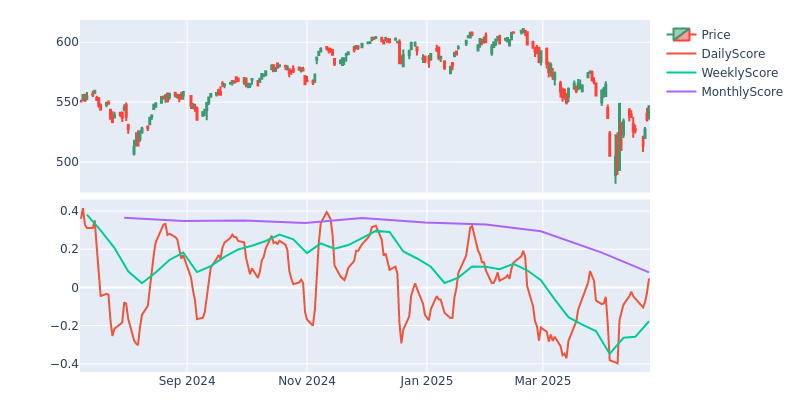

saved file: ../../../data/market_data/equity/QQQ.pkl


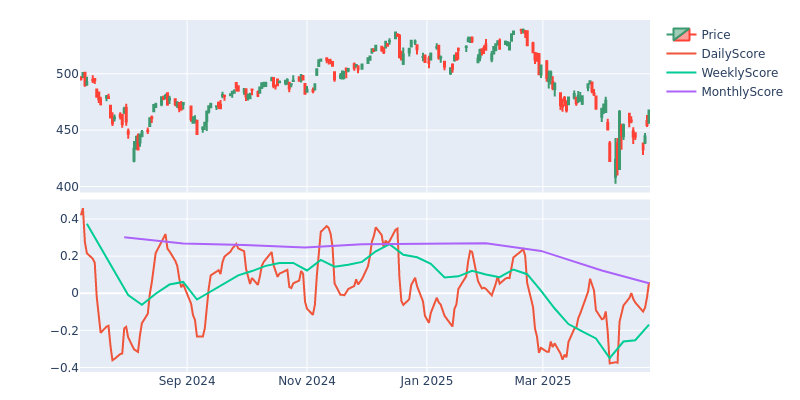

saved file: ../../../data/market_data/equity/IWM.pkl


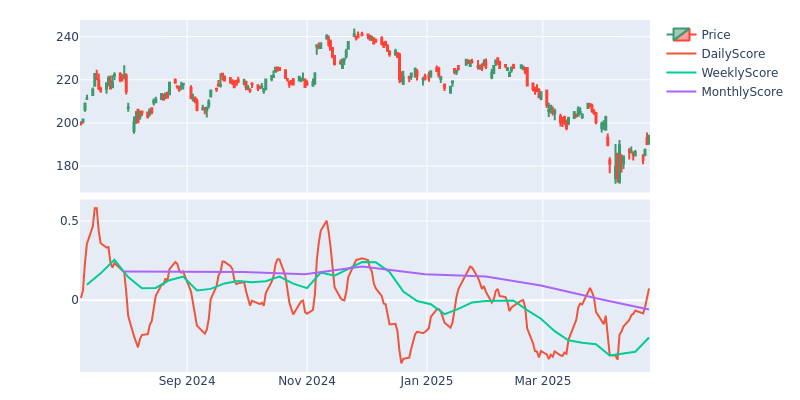

saved file: ../../../data/market_data/equity/GLD.pkl


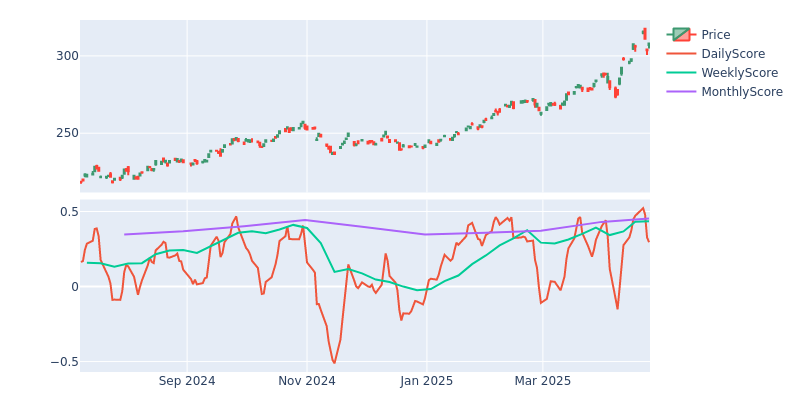

saved file: ../../../data/market_data/equity/SLV.pkl


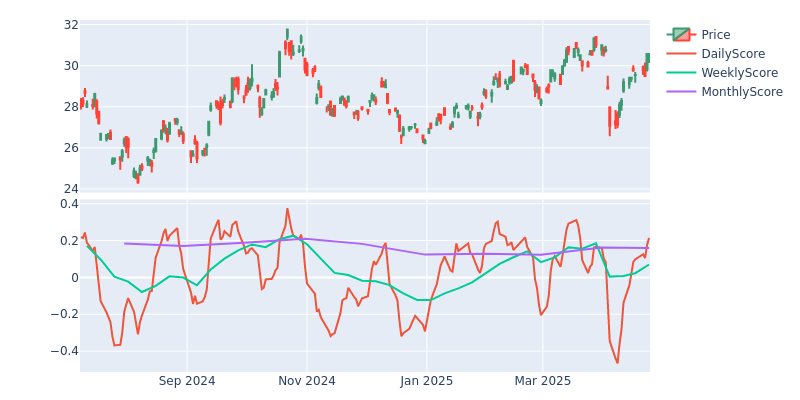

saved file: ../../../data/market_data/equity/CPER.pkl


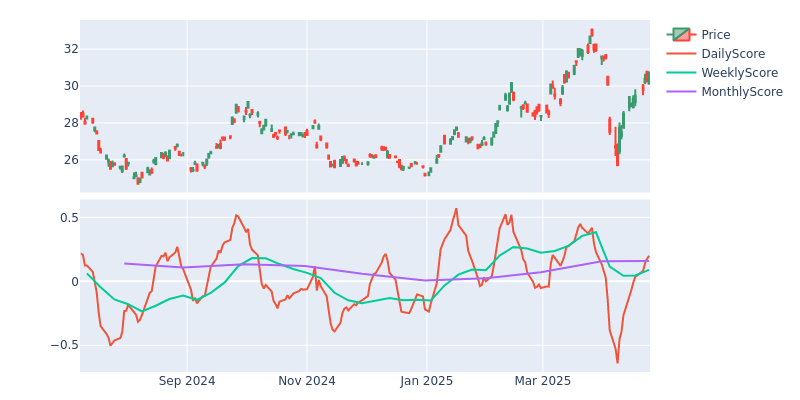

saved file: ../../../data/market_data/equity/USO.pkl


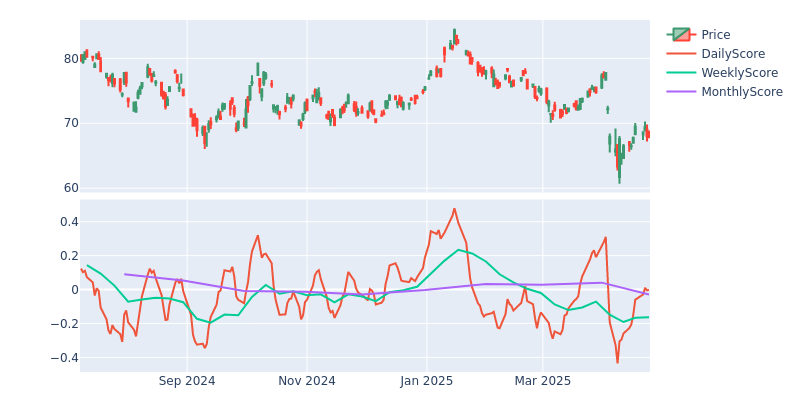

saved file: ../../../data/market_data/equity/TLT.pkl


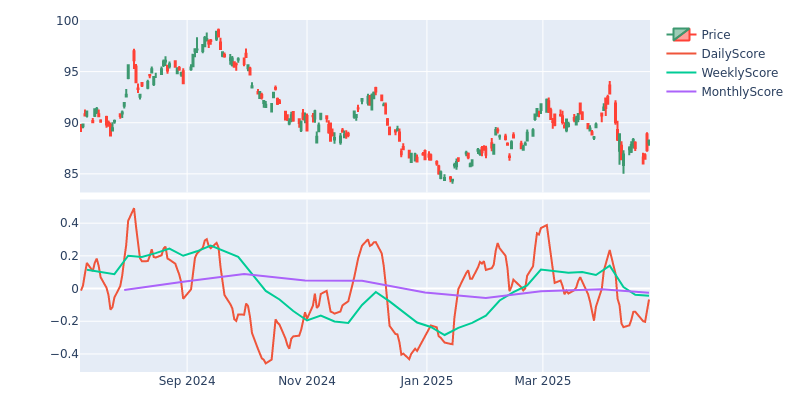

saved file: ../../../data/market_data/equity/KWEB.pkl


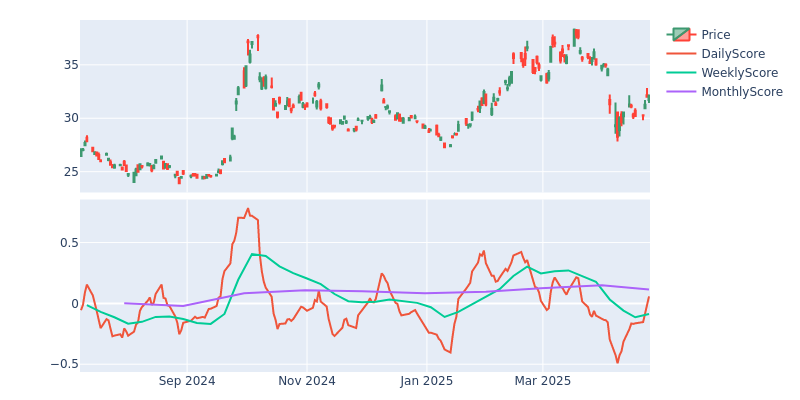

saved file: ../../../data/market_data/equity/PPA.pkl


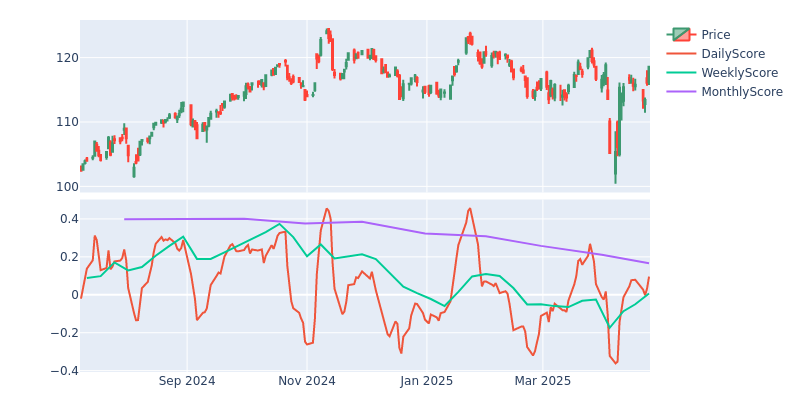

saved file: ../../../data/market_data/equity/IBIT.pkl


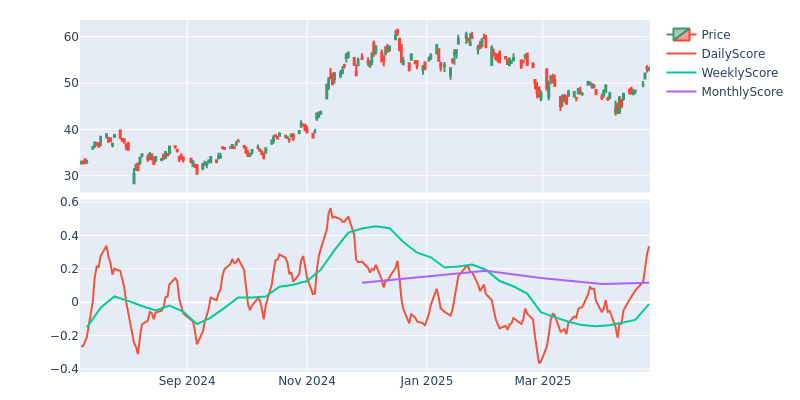

saved file: ../../../data/market_data/equity/XLF.pkl


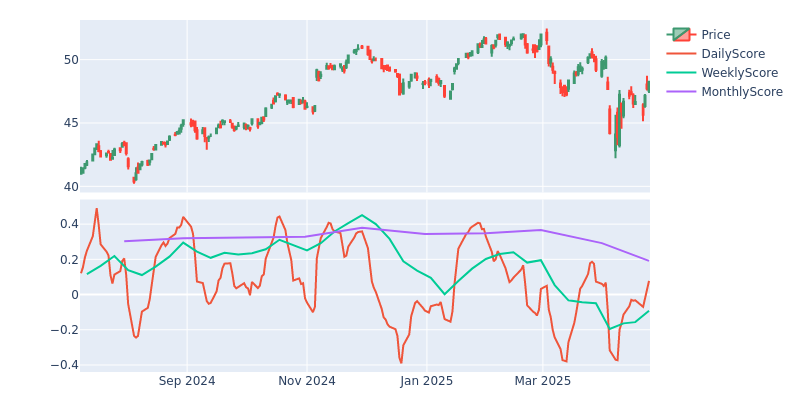

saved file: ../../../data/market_data/equity/XLI.pkl


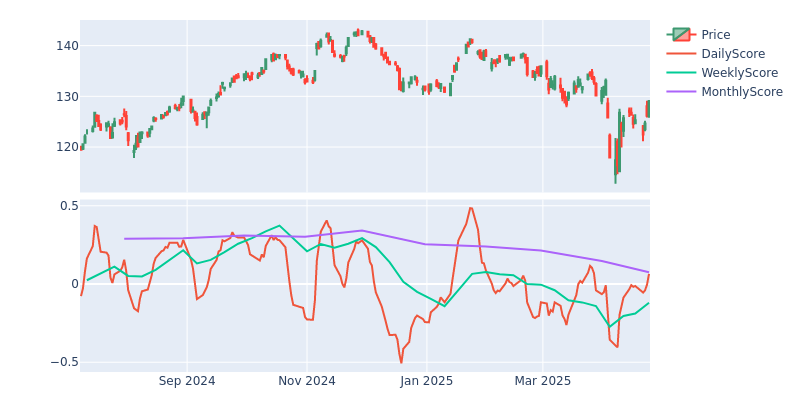

saved file: ../../../data/market_data/equity/XLB.pkl


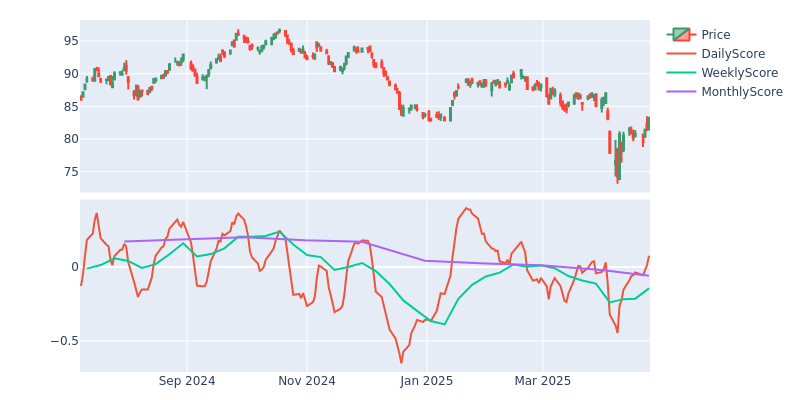

saved file: ../../../data/market_data/equity/XLC.pkl


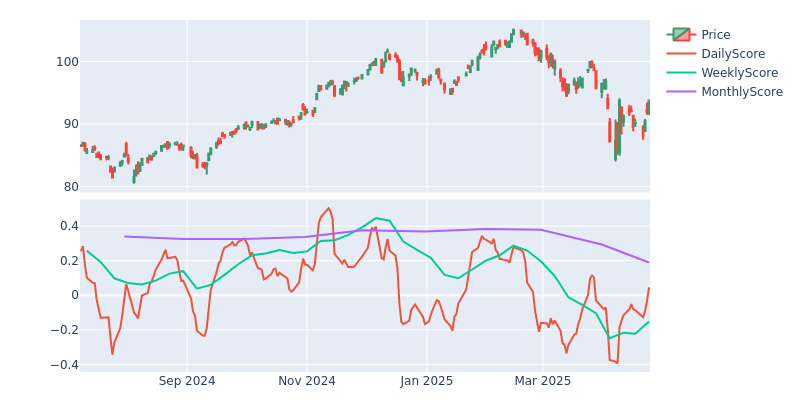

saved file: ../../../data/market_data/equity/XLY.pkl


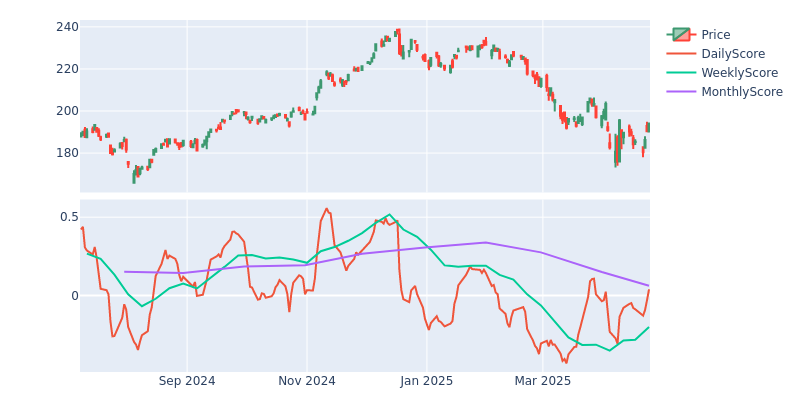

saved file: ../../../data/market_data/equity/XLP.pkl


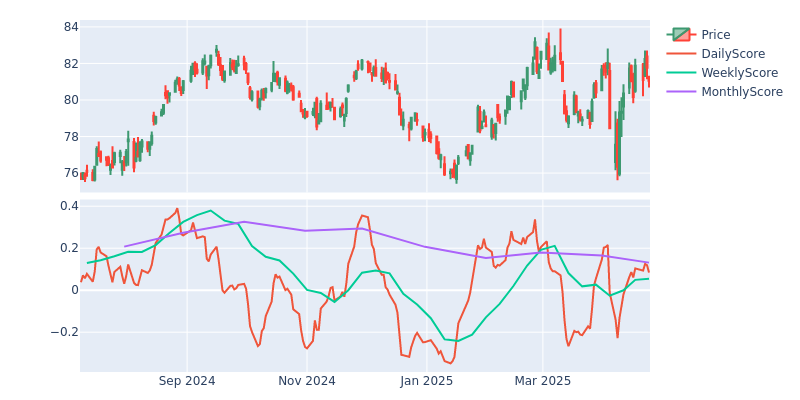

saved file: ../../../data/market_data/equity/XLV.pkl


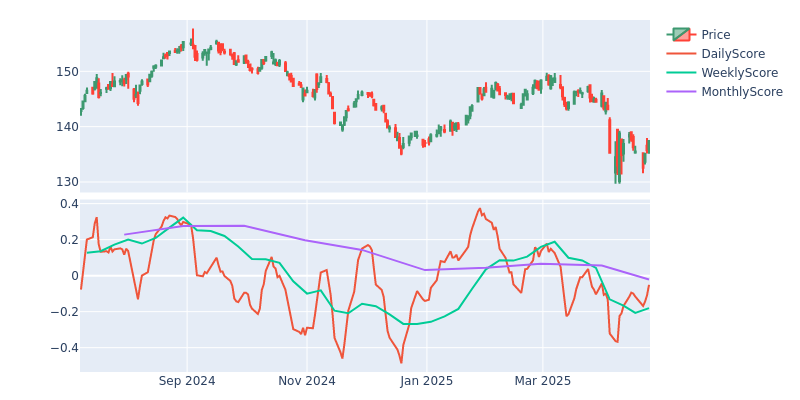

saved file: ../../../data/market_data/equity/XBI.pkl


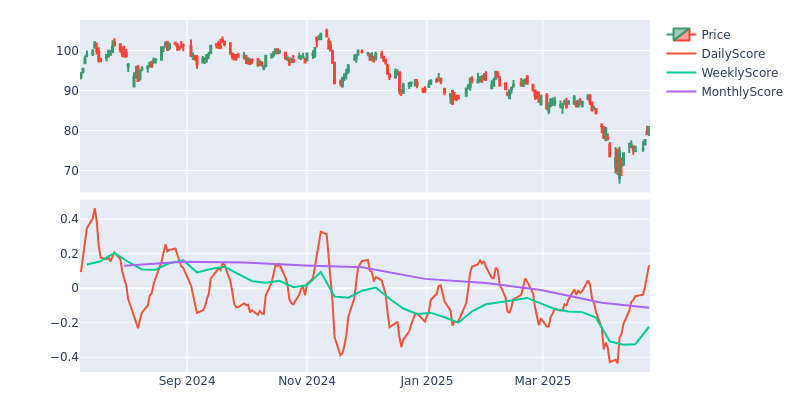

saved file: ../../../data/market_data/equity/XLK.pkl


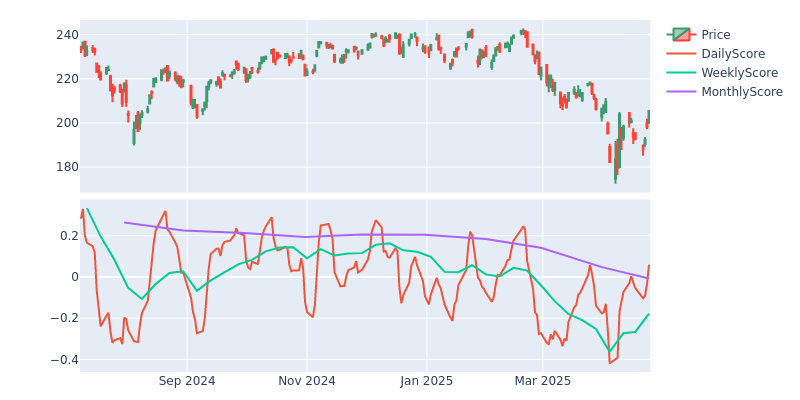

saved file: ../../../data/market_data/equity/XLU.pkl


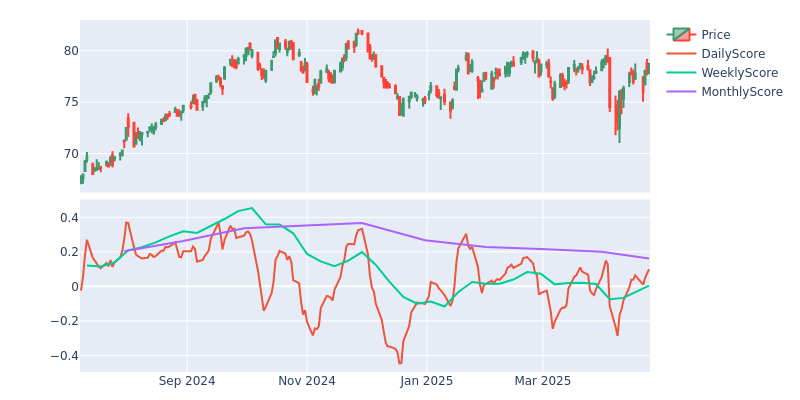

saved file: ../../../data/market_data/equity/XME.pkl


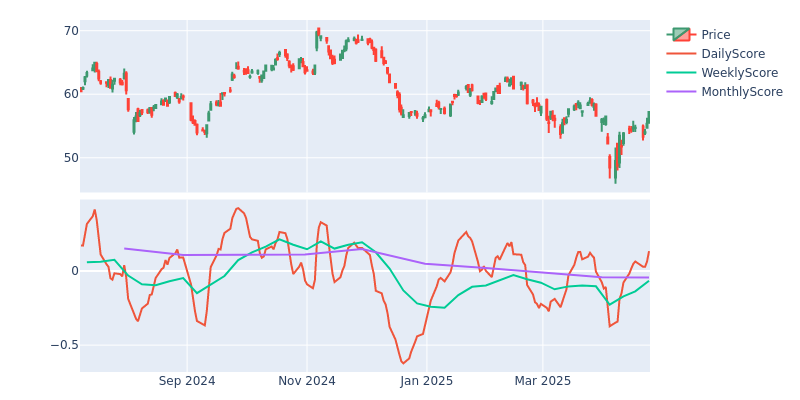

saved file: ../../../data/market_data/equity/MRVL.pkl


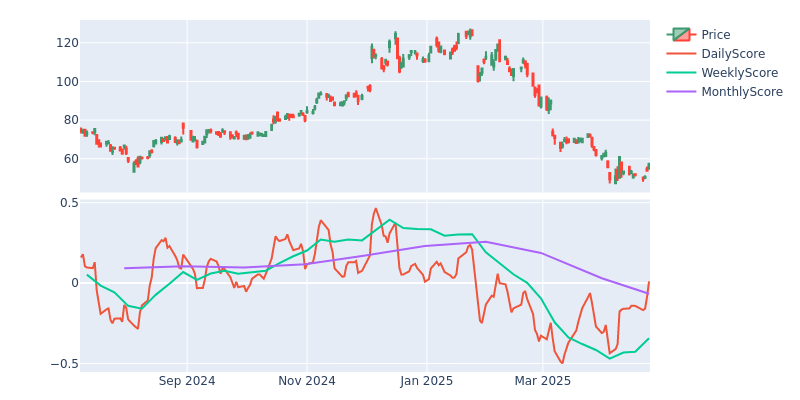

saved file: ../../../data/market_data/equity/ADBE.pkl


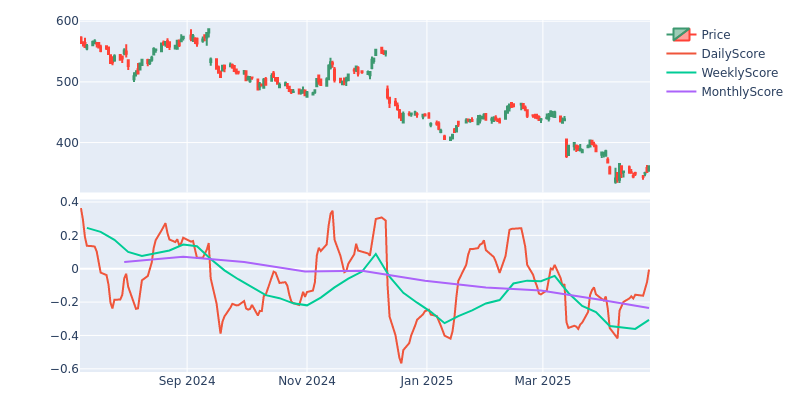

saved file: ../../../data/market_data/equity/ANET.pkl


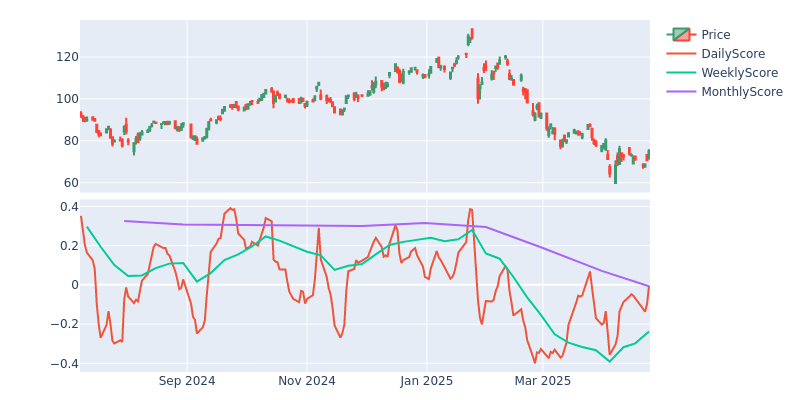

saved file: ../../../data/market_data/equity/PWR.pkl


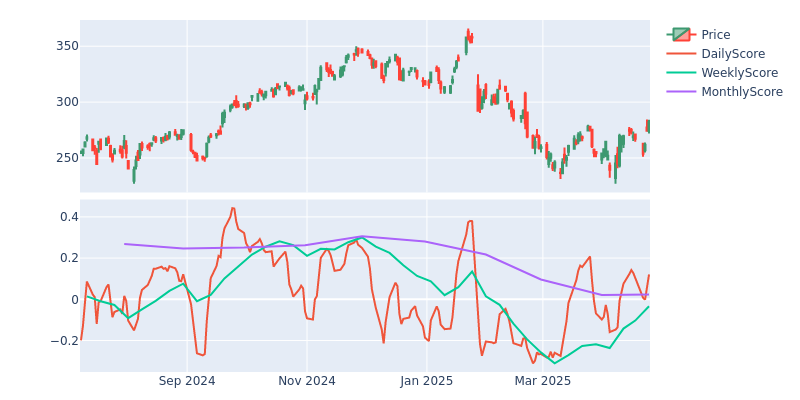

saved file: ../../../data/market_data/equity/AMD.pkl


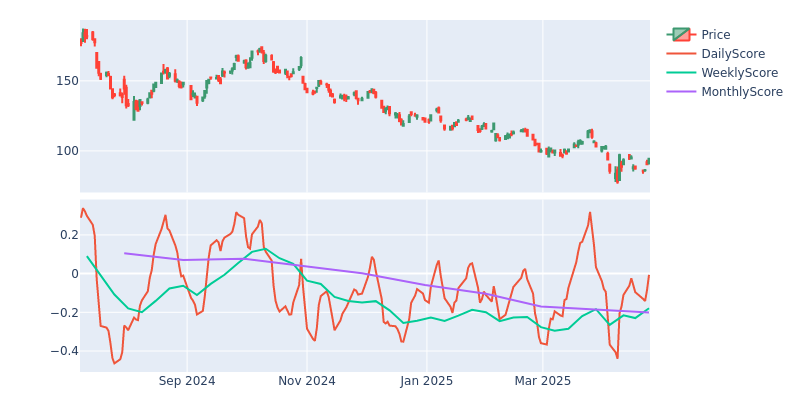

saved file: ../../../data/market_data/equity/GOOGL.pkl


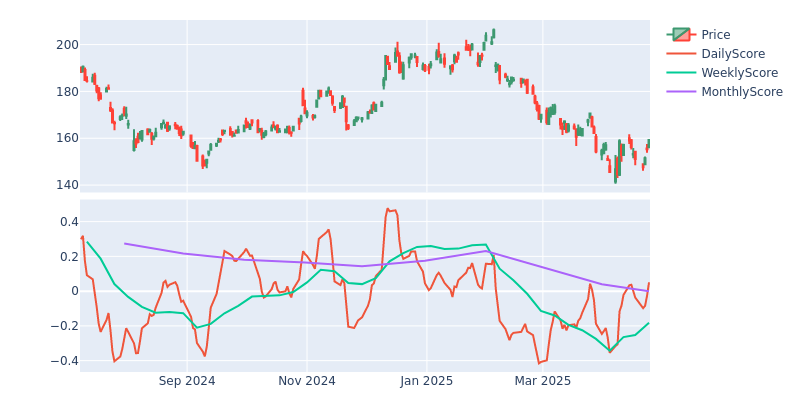

saved file: ../../../data/market_data/equity/NVDA.pkl


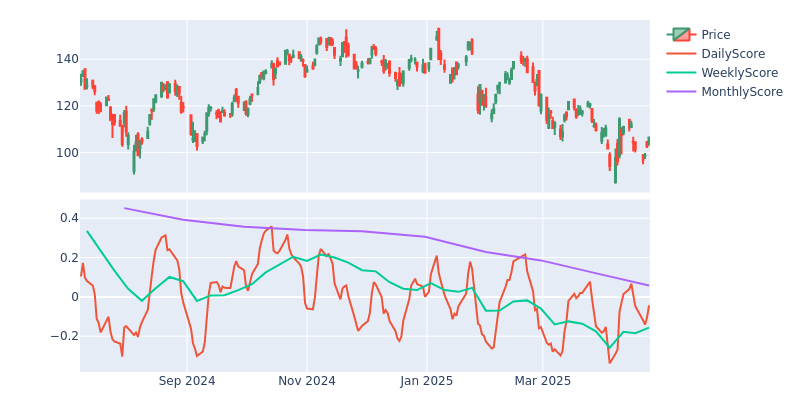

saved file: ../../../data/market_data/equity/META.pkl


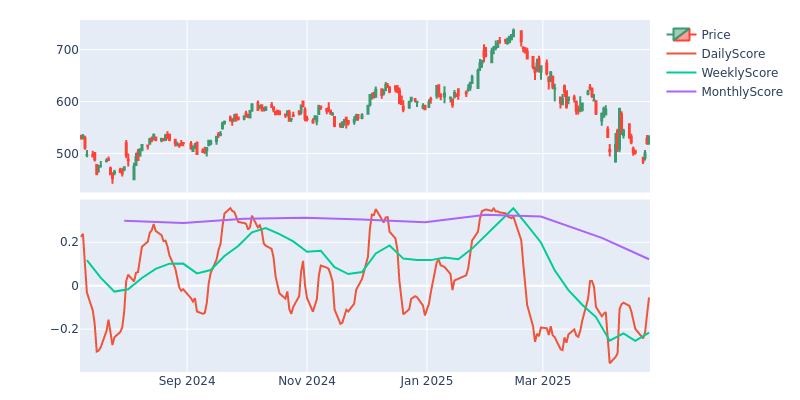

saved file: ../../../data/market_data/equity/ASML.pkl


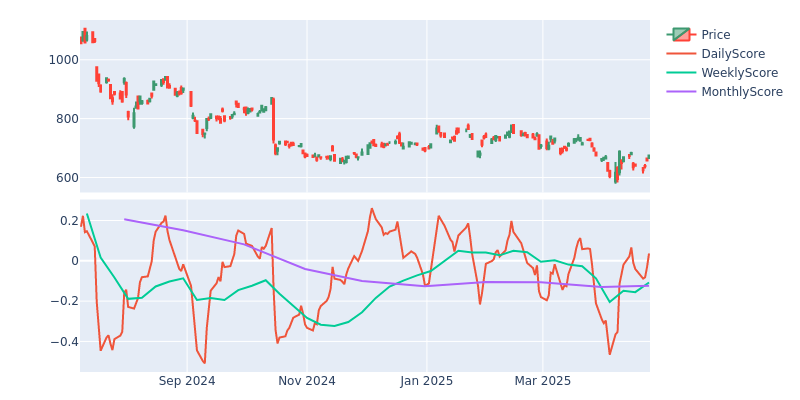

saved file: ../../../data/market_data/equity/TSLA.pkl


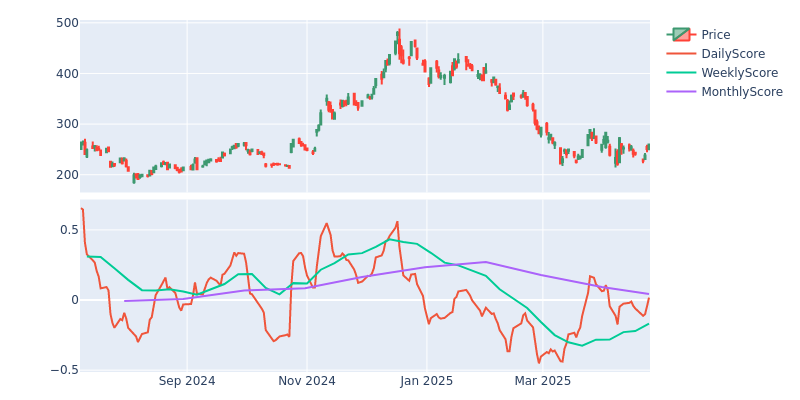

saved file: ../../../data/market_data/equity/PFE.pkl


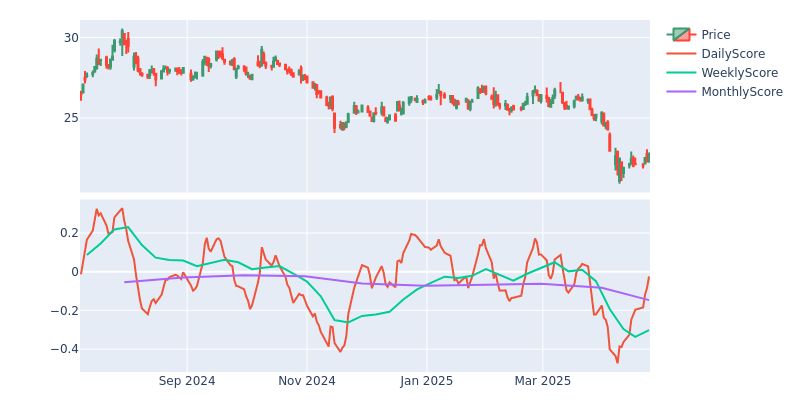

saved file: ../../../data/market_data/equity/IWM.pkl


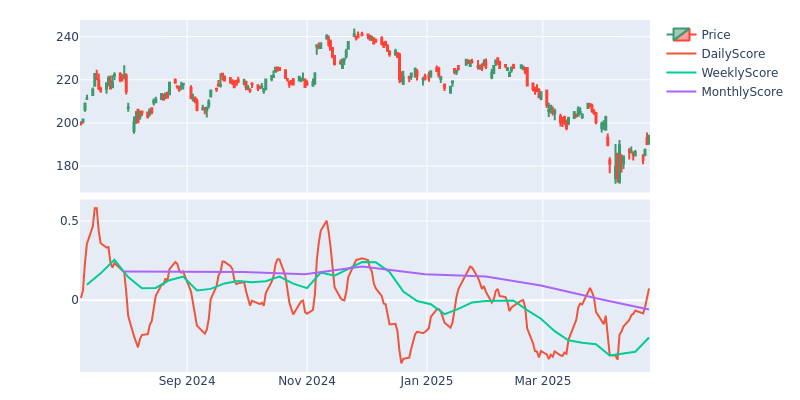

saved file: ../../../data/market_data/equity/AVGO.pkl


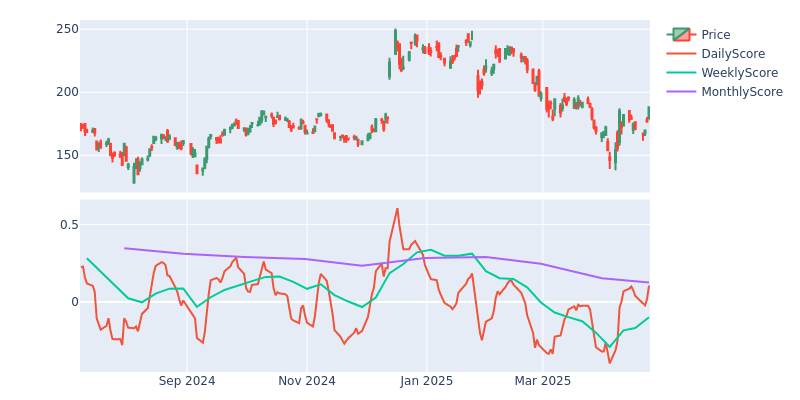

saved file: ../../../data/market_data/equity/FTNT.pkl


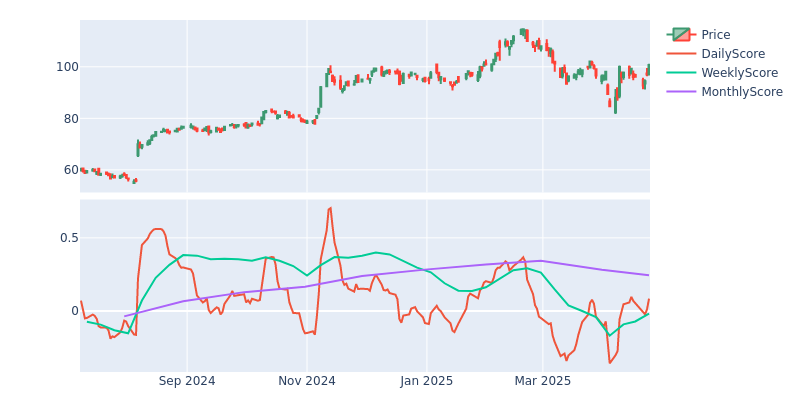

saved file: ../../../data/market_data/equity/MMM.pkl


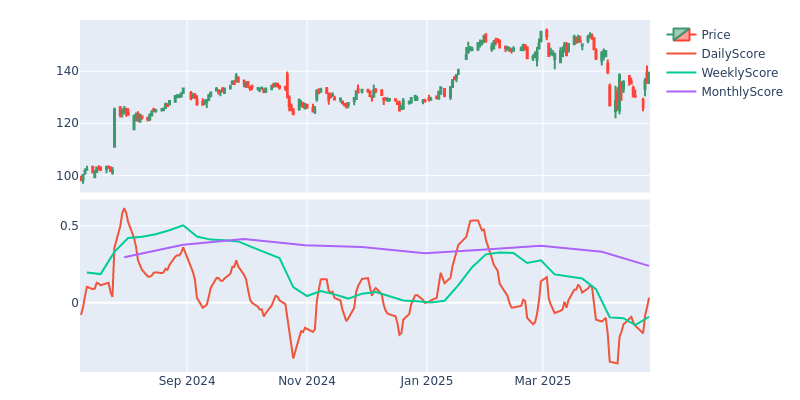

saved file: ../../../data/market_data/equity/TRV.pkl


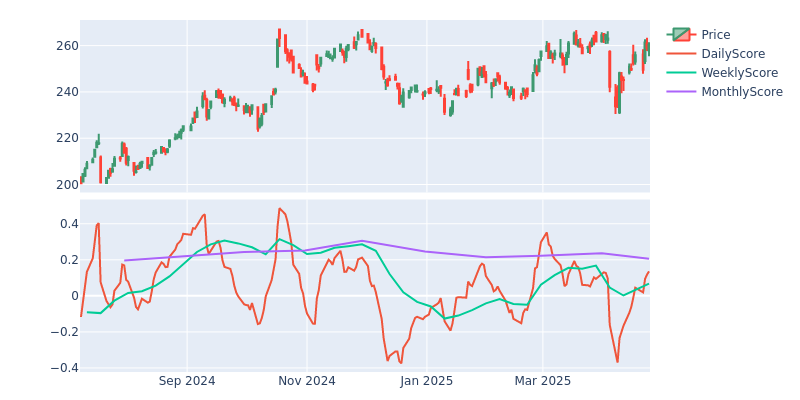

saved file: ../../../data/market_data/equity/LMT.pkl


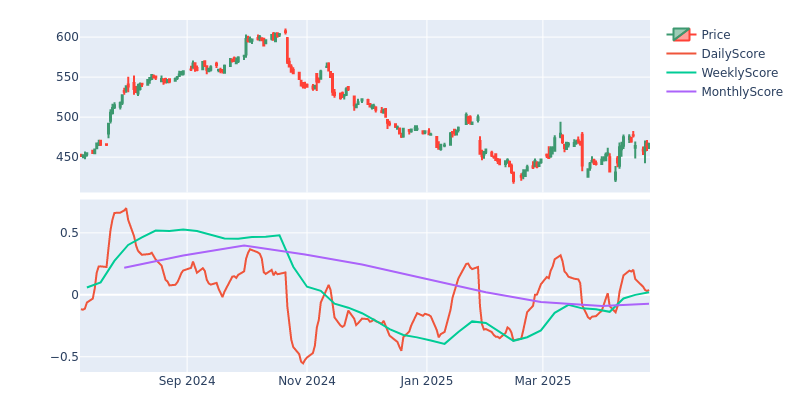

saved file: ../../../data/market_data/equity/JPY=X.pkl


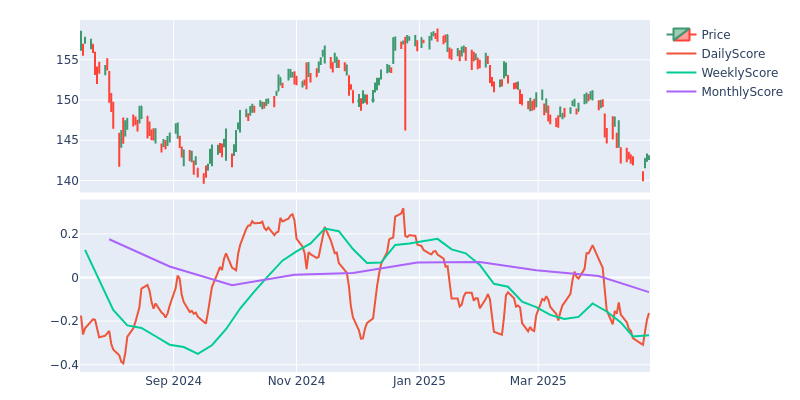

saved file: ../../../data/market_data/equity/GBPUSD=X.pkl


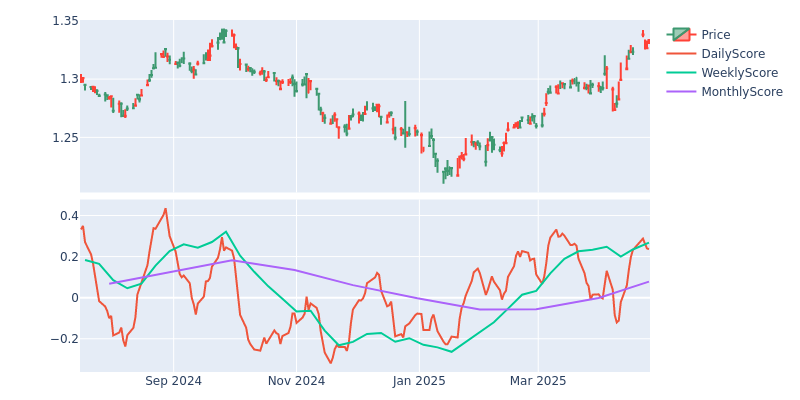

saved file: ../../../data/market_data/equity/AUDUSD=X.pkl


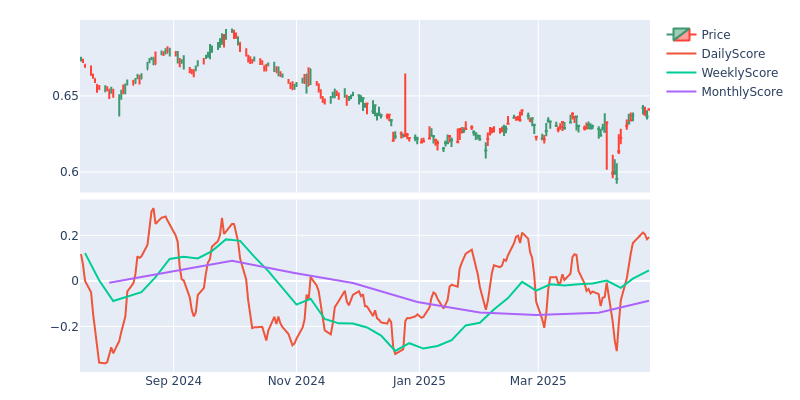

saved file: ../../../data/market_data/equity/EURUSD=X.pkl


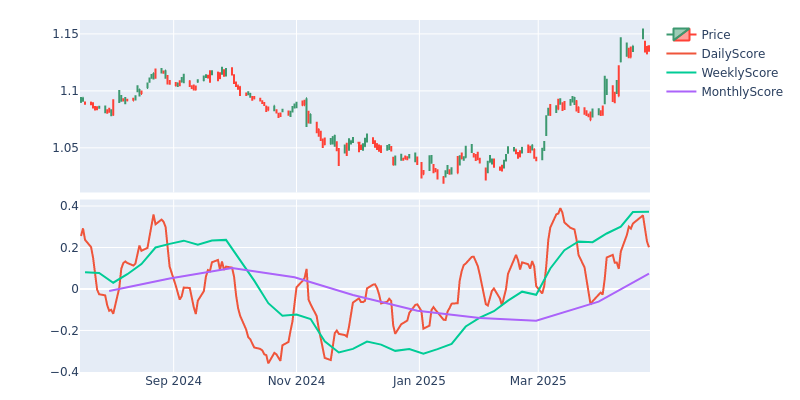

saved file: ../../../data/market_data/equity/CADUSD=X.pkl


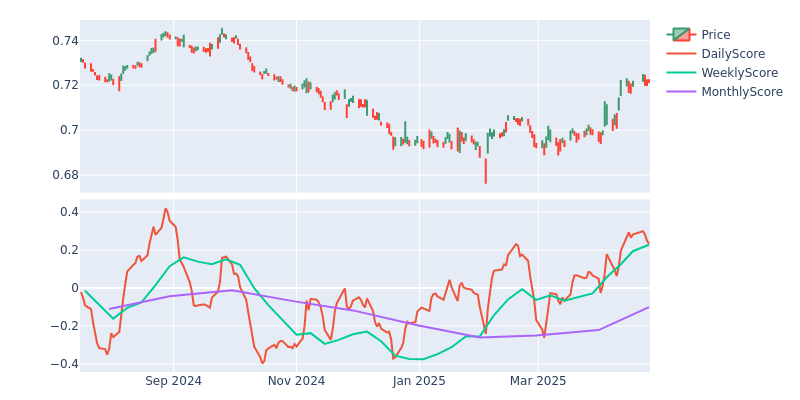

In [ ]:
pio.renderers.default = os.environ.get("PLOTLY_RENDERER", "png")
resample_rule = "1D"
rule_period_map = {"1D": "2y", "1W": "10y", "1M": "20y"}
period = rule_period_map[resample_rule]
future = ["^SPX", "^NDX", "^RUT", "GC=F", "HG=F", "SI=F", "CL=F", "TLT", "KWEB"]
single_name = [
    "MRVL",
    "ADBE",
    "ANET",
    "PWR",
    "AMD",
    "GOOGL",
    "NVDA",
    "META",
    "ASML",
    "TSLA",
    "PFE",
    "IWM",
    "AVGO",
    "FTNT",
    "MMM",
    "TRV",
    "LMT",
]
etf = [
    "SPY",
    "QQQ",
    "IWM",
    "GLD",
    "SLV",
    "CPER",
    "USO",
    "TLT",
    "KWEB",
    "PPA",
    "IBIT",
    "XLF",
    "XLI",
    "XLB",
    "XLC",
    "XLY",
    "XLP",
    "XLV",
    "XBI",
    "XLK",
    "XLU",
    "XME",
]
fx = ["JPY=X", "GBPUSD=X", "AUDUSD=X", "EURUSD=X", "CADUSD=X"]
for sym in etf + single_name + fx:
    # ticker = Ticker(sym, data_mode = Ticker.DATAMODE.LOCAL, local_data_folder = '../../../data/market_data/')
    ticker = TickerDatabase(sym)
    df = Candle(ticker.history(period=period))
    trend_score_dict = get_trend_score_multi_horizon(df.log(), short=5, long=10)
    fig = plot(df.iloc[-200:], trend_score_dict)
    fig.show()